<a href="https://colab.research.google.com/github/unnatim027/Deepfake-Call-Detector/blob/main/audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asvpoof-2019-dataset' dataset.
Path to dataset files: /kaggle/input/asvpoof-2019-dataset


In [ ]:
import os

print("Path to dataset files:", path)
for root, dirs, files in os.walk(path):
    print(root)
    break  # just to see top-level folders


Path to dataset files: /kaggle/input/asvpoof-2019-dataset
/kaggle/input/asvpoof-2019-dataset


In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1"

for item in os.listdir(base_path):
    print(item)


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1'

In [ ]:
import os

la_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA"

for folder in os.listdir(la_path):
    print(folder)



FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA'

In [ ]:
import os

la_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/la"

for root, dirs, files in os.walk(la_path):
    print(root)
    break  # just print the first level


In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1"
print("Base path exists:", os.path.exists(base_path))
print("Folders under base path:")
print(os.listdir(base_path))


Base path exists: False
Folders under base path:


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1'

In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA"

print("Checking what's inside LA:")
for item in os.listdir(base_path):
    item_path = os.path.join(base_path, item)
    print("📁", item_path, " | Directory:", os.path.isdir(item_path))



Checking what's inside LA:
📁 /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA  | Directory: True


In [ ]:
subfolders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
if subfolders:
    deeper_path = os.path.join(base_path, subfolders[0])
    print("Exploring:", deeper_path)
    print(os.listdir(deeper_path))


Exploring: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA
['ASVspoof2019_LA_train', 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019_LA_dev', 'README.LA.txt', 'ASVspoof2019_LA_asv_scores', 'ASVspoof2019_LA_eval', 'ASVspoof2019_LA_asv_protocols']


In [ ]:
import os

# Base LA folder path
base_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA"

# Print *everything* inside recursively, only 2 levels deep
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    if level < 2:
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        for d in dirs:
            print(f"{indent}  {d}/")



LA/
  LA/
  LA/
    ASVspoof2019_LA_train/
    ASVspoof2019_LA_cm_protocols/
    ASVspoof2019_LA_dev/
    ASVspoof2019_LA_asv_scores/
    ASVspoof2019_LA_eval/
    ASVspoof2019_LA_asv_protocols/


In [ ]:
import os
import pandas as pd
import librosa

# ✅ Correct final base path
base_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA"

# Subpaths
train_path = os.path.join(base_path, "ASVspoof2019_LA_train")
protocol_train = os.path.join(base_path, "ASVspoof2019_LA_cm_protocols", "ASVspoof2019.LA.cm.train.trn.txt")

print("Base path:", base_path)
print("Train path:", train_path)
print("Protocol path:", protocol_train)
print("Train exists:", os.path.exists(train_path))
print("Protocol exists:", os.path.exists(protocol_train))




Base path: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA
Train path: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train
Protocol path: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
Train exists: True
Protocol exists: True


In [ ]:
# Load the train protocol
df_train = pd.read_csv(protocol_train, sep=' ', header=None)
df_train.columns = ['speaker_id', 'file_name', 'system_id', 'attack_id', 'label']
print(df_train.head())

# Load a single training audio file
audio_file = os.path.join(train_path, "flac", df_train.iloc[0]['file_name'] + ".flac")

y, sr = librosa.load(audio_file, sr=None)
print("Loaded:", audio_file)
print("Audio shape:", y.shape)
print("Sample rate:", sr)


  speaker_id     file_name system_id attack_id     label
0    LA_0079  LA_T_1138215         -         -  bonafide
1    LA_0079  LA_T_1271820         -         -  bonafide
2    LA_0079  LA_T_1272637         -         -  bonafide
3    LA_0079  LA_T_1276960         -         -  bonafide
4    LA_0079  LA_T_1341447         -         -  bonafide
Loaded: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1138215.flac
Audio shape: (55329,)
Sample rate: 16000


In [ ]:
df_train['label'].value_counts()


,count
label,
spoof,22800
bonafide,2580


In [ ]:
y_labels.append(1 if row['label'] == 'bonafide' else 0)


NameError: name 'y_labels' is not defined

In [ ]:
y_labels.append(1 if row['label'] == 'bonafide' else 0)


NameError: name 'y_labels' is not defined

In [ ]:
import numpy as np
import librosa
import librosa.display
from tqdm import tqdm

def extract_features(file_path, n_mfcc=40, max_len=400):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Pad or truncate to fixed length for model input
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

# Extract MFCCs for a small subset (for testing)
subset = df_train.sample(10, random_state=42)
X, y_labels = [], []

for _, row in tqdm(subset.iterrows(), total=len(subset)):
    audio_file = os.path.join(train_path, "flac", row['file_name'] + ".flac")
    X.append(extract_features(audio_file))
    y_labels.append(1 if row['label'] == 'bonafide' else 0)

X = np.array(X)
y = np.array(y_labels)

print("Feature shape:", X.shape)
print("Labels:", y)

100%|██████████| 10/10 [00:00<00:00, 64.50it/s]

Feature shape: (10, 40, 400)
Labels: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
df_train['label'].unique()



array(['bonafide', 'spoof'], dtype=object)

In [ ]:
df_train.head(20)


,speaker_id,file_name,system_id,attack_id,label
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide
5,LA_0079,LA_T_1363611,-,-,bonafide
6,LA_0079,LA_T_1596451,-,-,bonafide
7,LA_0079,LA_T_1608170,-,-,bonafide
8,LA_0079,LA_T_1684951,-,-,bonafide
9,LA_0079,LA_T_1699801,-,-,bonafide


In [ ]:
print(df_train['label'].value_counts())


label
spoof       22800
bonafide     2580
Name: count, dtype: int64


In [ ]:
import numpy as np

# Equal samples from each class for testing
bonafide_samples = df_train[df_train['label'] == 'bonafide'].sample(5, random_state=42)
spoof_samples = df_train[df_train['label'] == 'spoof'].sample(5, random_state=42)

subset = pd.concat([bonafide_samples, spoof_samples])
print(subset['label'].value_counts())

# Extract MFCC features again
X, y_labels = [], []

for _, row in subset.iterrows():
    audio_file = os.path.join(train_path, "flac", row['file_name'] + ".flac")
    if os.path.exists(audio_file):
        X.append(extract_features(audio_file))
        y_labels.append(1 if row['label'] == 'bonafide' else 0)
    else:
        print("Missing:", audio_file)

X = np.array(X)
y = np.array(y_labels)

print("✅ Feature shape:", X.shape)
print("✅ Labels:", y)


label
bonafide    5
spoof       5
Name: count, dtype: int64
✅ Feature shape: (10, 40, 400)
✅ Labels: [1 1 1 1 1 0 0 0 0 0]


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, LSTM, Bidirectional, Reshape)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Assuming you already have your preprocessed arrays:
# X → features, shape (samples, 40, 400)
# y → labels, shape (samples, )

print("X shape:", X.shape)
print("y shape:", y.shape)

# Reshape for CNN input (add a channel dimension)
X_cnn = X[..., np.newaxis]  # becomes (samples, 40, 400, 1)
print("X_cnn shape:", X_cnn.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "Test set:", X_test.shape)


X shape: (10, 40, 400)
y shape: (10,)
X_cnn shape: (10, 40, 400, 1)
Train set: (8, 40, 400, 1) Test set: (2, 40, 400, 1)


In [ ]:
# CNN Model for Spoof Detection
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(40, 400, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.summary()

# Train (use few epochs for test)
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=2,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 38, 398, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 398, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 197, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 197, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 98, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 96, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 96, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 48, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,121 (9.36 MB)

 Trainable params: 2,452,673 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 311ms/step - accuracy: 0.3667 - loss: 3.4249 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5500 - loss: 4.9461 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8667 - loss: 0.3010 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 2.2469e-04 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5333 - loss: 5.0046 - val_accuracy: 1.0000 - val_loss: 1.1070e-11
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9500 - loss: 0.1257 - val_accuracy: 1.0000 - val_loss: 5.8260e-14
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 1.9571e-06 - val_accuracy: 1.0000 - val_loss: 1.6084e-09
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9167 - loss: 0.1271 - val_accuracy: 1.000

In [ ]:
# Hybrid CNN + BiLSTM
hybrid_model = Sequential([
    # CNN layers
    Conv2D(32, (3,3), activation='relu', input_shape=(40, 400, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Flatten time dimension for LSTM
    Reshape((64, -1)),

    # LSTM layers
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

hybrid_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hybrid_model.summary()

history_hybrid = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=2,
    verbose=1
)


NameError: name 'Sequential' is not defined

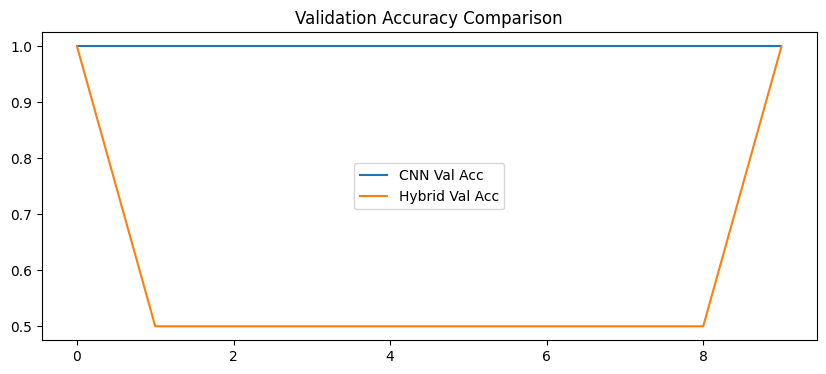

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc')
plt.plot(history_hybrid.history['val_accuracy'], label='Hybrid Val Acc')
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()


In [ ]:
import os

# Check a few sample paths
for i in range(3):
    row = df_subset.iloc[i]
    file_path = os.path.join(train_path, 'flac', row['file_name'] + '.flac')
    print("Checking:", file_path)
    print("Exists:", os.path.exists(file_path))




Checking: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1136756.flac
Exists: True
Checking: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac/LA_T_9760660.flac
Exists: True
Checking: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train/flac/LA_T_6436847.flac
Exists: True


In [ ]:
def extract_features(df):
    import librosa, numpy as np
    from tqdm import tqdm

    features, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        file_path = os.path.join(train_path, 'flac', row['file_name'] + '.flac')
        if os.path.exists(file_path):
            try:
                y, sr = librosa.load(file_path, sr=16000)
                if len(y) == 0:  # skip empty audio
                    continue
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
                mfcc = librosa.util.fix_length(mfcc, size=400, axis=1)
                features.append(mfcc)
                labels.append(1 if row['label'] == 'spoof' else 0)
            except Exception as e:
                print(f"⚠️ Error reading {file_path}: {e}")
                continue
    return np.array(features), np.array(labels)


In [ ]:
df_subset = df_train.sample(n=1000, random_state=42)
features, labels = extract_features(df_subset)


100%|██████████| 1000/1000 [00:12<00:00, 80.68it/s]


In [ ]:
print("Feature shape:", features.shape)
print("Label counts:", np.unique(labels, return_counts=True))


Feature shape: (1000, 40, 400)
Label counts: (array([0, 1]), array([ 92, 908]))


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Reshape for CNN input
X = np.expand_dims(features, -1)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (800, 40, 400, 1) Test: (200, 40, 400, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(40, 400, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 38, 398, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 38, 398, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 19, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 197, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 17, 197, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 98, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 96, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 96, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 48, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,121 (9.36 MB)

 Trainable params: 2,452,673 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8641 - loss: 1.1676 - val_accuracy: 0.9100 - val_loss: 1.1618
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9030 - loss: 0.2850 - val_accuracy: 0.9100 - val_loss: 0.3273
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9089 - loss: 0.2335 - val_accuracy: 0.9100 - val_loss: 0.1703
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9152 - loss: 0.1688 - val_accuracy: 0.9100 - val_loss: 0.1357
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9086 - loss: 0.1583 - val_accuracy: 0.8700 - val_loss: 0.4065
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9307 - loss: 0.1904 - val_accuracy: 0.9400 - val_loss: 0.2480
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9397 - loss: 0.1577 - val_accuracy: 0.9100 - val_loss: 0.1459
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9081 - loss: 0.1973 - val_accuracy: 0.9450 - 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Reshape, Bidirectional, LSTM, Dropout, Dense

hybrid_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(40, 400, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Reshape((64, 784)),  # Flatten spatial dims for LSTM input
    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

hybrid_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hybrid_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 38, 398, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 38, 398, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 19, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 17, 197, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 17, 197, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 98, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 64, 784)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       434,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,209 (1.76 MB)

 Trainable params: 462,017 (1.76 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
hybrid_history = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8553 - loss: 0.3913 - val_accuracy: 0.9100 - val_loss: 0.2793
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9192 - loss: 0.2652 - val_accuracy: 0.9100 - val_loss: 0.2520
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9072 - loss: 0.2542 - val_accuracy: 0.9100 - val_loss: 0.2700
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9145 - loss: 0.2192 - val_accuracy: 0.9100 - val_loss: 0.2139
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9044 - loss: 0.1941 - val_accuracy: 0.9050 - val_loss: 0.1832
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9121 - loss: 0.1738 - val_accuracy: 0.9500 - val_loss: 0.1310
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9458 - loss: 0.1308 - val_accuracy: 0.9100 - val_loss: 0.1459
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9642 - loss: 0.0910 - val_accuracy: 0.9300 - v

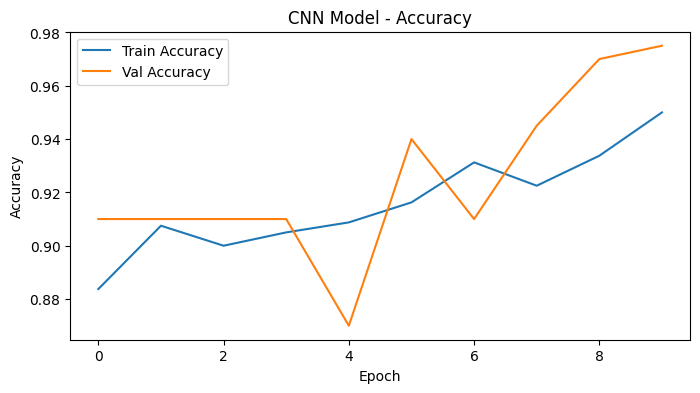

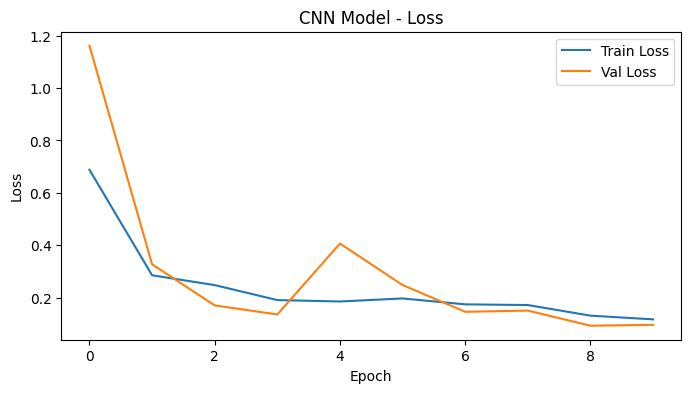

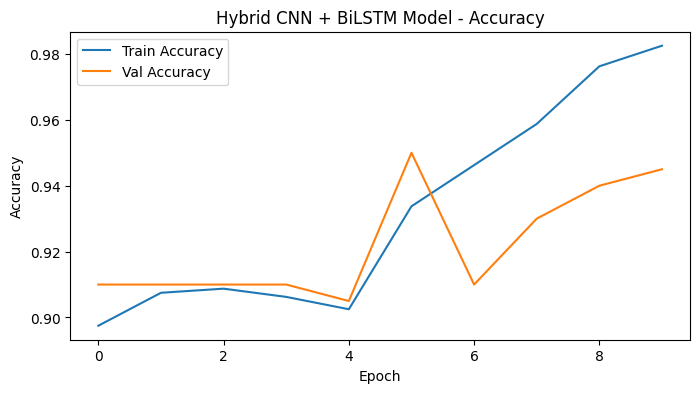

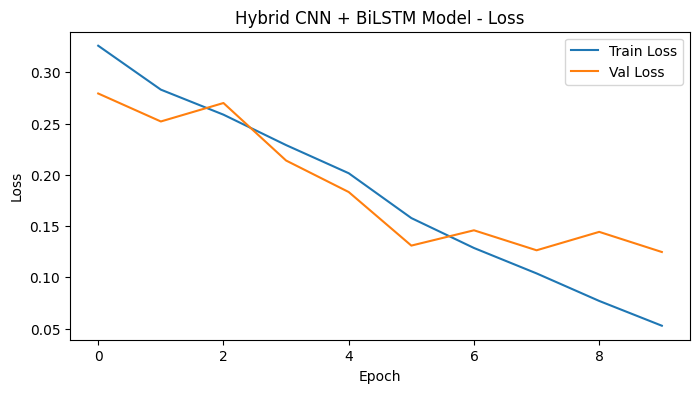

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(8,4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Plot CNN and Hybrid curves
plot_history(cnn_history, "CNN Model")
plot_history(hybrid_history, "Hybrid CNN + BiLSTM Model")


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# CNN Evaluation
cnn_preds = (cnn_model.predict(X_test) > 0.5).astype("int32")
print("📈 CNN Model Evaluation")
print(classification_report(y_test, cnn_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, cnn_preds))

# Hybrid Evaluation
hyb_preds = (hybrid_model.predict(X_test) > 0.5).astype("int32")
print("\n📈 Hybrid CNN + BiLSTM Model Evaluation")
print(classification_report(y_test, hyb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, hyb_preds))


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step
📈 CNN Model Evaluation
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        18
           1       0.98      0.99      0.99       182

    accuracy                           0.97       200
   macro avg       0.96      0.89      0.92       200
weighted avg       0.97      0.97      0.97       200

Confusion Matrix:
 [[ 14   4]
 [  1 181]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

📈 Hybrid CNN + BiLSTM Model Evaluation
              precision    recall  f1-score   support

           0       0.82      0.50      0.62        18
           1       0.95      0.99      0.97       182

    accuracy                           0.94       200
   macro avg       0.89      0.74      0.80       200
weighted avg       0.94      0.94      0.94       200

Confusion Matrix:
 [[  9   9]
 [  2 180]]


In [ ]:
# ✅ Save CNN model
cnn_model.save("cnn_asvspoof_model.h5")

# ✅ Save Hybrid model
hybrid_model.save("hybrid_asvspoof_model.h5")


In [ ]:
train_path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA/ASVspoof2019_LA_train"
df_train   # dataframe with 'file_name' and 'label' columns


,speaker_id,file_name,system_id,attack_id,label
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide
...,...,...,...,...,...
25375,LA_0098,LA_T_9717580,-,A06,spoof
25376,LA_0098,LA_T_9779814,-,A06,spoof
25377,LA_0098,LA_T_9783312,-,A06,spoof
25378,LA_0098,LA_T_9839348,-,A06,spoof


In [ ]:
SAMPLE_N = 5000   # if you have more RAM


In [ ]:
pip install librosa tqdm


Samples to extract: 5000


100%|██████████| 5000/5000 [01:03<00:00, 79.21it/s]


Feature shape: (5000, 40, 400, 3)  | Labels shape: (5000,)
Train: (4000, 40, 400, 3) Test: (1000, 40, 400, 3)
Class weights: {0: np.float64(0.5549389567147613), 1: np.float64(5.05050505050505)}


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 40, 400,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 40, 400,   │          0 │ input_layer_13[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 40, 400,   │        896 │ lambda_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 400,   │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 20, 200,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 20, 200,   │     18,496 │ max_pooling2d_22… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 200,   │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 10, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 10, 6400)  │          0 │ max_pooling2d_23… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_14    │ (None, 10, 256)   │  6,685,696 │ reshape_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 10, 256)   │          0 │ bidirectional_14… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_15    │ (None, 10, 128)   │    164,352 │ dropout_22[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 10, 128)   │          0 │ bidirectional_15… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 10, 64)    │      8,256 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 10, 1)     │         65 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 10, 1)     │          0 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 10, 128)   │          0 │ dropout_23[0][0], │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply_4[0][0]  │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 6,894,786 (26.30 MB)

 Trainable params: 6,894,594 (26.30 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.7117 - auc: 0.6759 - loss: 0.6743 - val_accuracy: 0.4930 - val_auc: 0.8003 - val_loss: 0.6795 - learning_rate: 1.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.6125 - auc: 0.7849 - loss: 0.5765 - val_accuracy: 0.5650 - val_auc: 0.8518 - val_loss: 0.6336 - learning_rate: 1.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8113 - auc: 0.9025 - loss: 0.4240 - val_accuracy: 0.6100 - val_auc: 0.9102 - val_loss: 0.6633 - learning_rate: 1.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8537 - auc: 0.9377 - loss: 0.3035 - val_accuracy: 0.8540 - val_auc: 0.9556 - val_loss: 0.3239 - learning_rate: 1.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8815 - auc: 0.9641 - loss: 0.2413 - val_accuracy: 0.8700 - val_auc: 0.9629 - val_loss: 0.2838 - learning_rate: 1.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step -

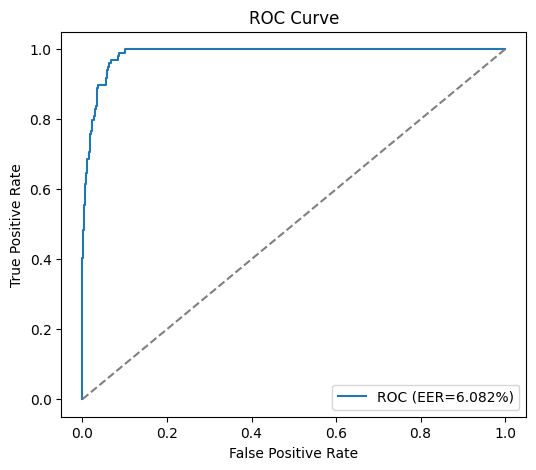

✅ Model saved as 'hybrid_bilstm_attention_model_final.keras'


In [ ]:
# ====== PARAMETERS ======
SAMPLE_N = 5000       # you can increase later if system allows
N_MFCC = 40
MAX_FRAMES = 400
SR = 16000
BATCH_SIZE = 32
EPOCHS = 25

# ====== IMPORTS ======
import os, numpy as np, librosa
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# ====== FEATURE EXTRACTION ======
def extract_mfcc_with_deltas(file_path, n_mfcc=N_MFCC, max_len=MAX_FRAMES, sr=SR):
    y, sr = librosa.load(file_path, sr=sr)
    if len(y) == 0:
        raise ValueError("Empty audio")
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    def fix(m):
        if m.shape[1] < max_len:
            pad = max_len - m.shape[1]
            return np.pad(m, ((0,0),(0,pad)), mode='constant')
        else:
            return m[:, :max_len]

    mfcc = fix(mfcc)
    delta = fix(delta)
    delta2 = fix(delta2)

    stacked = np.stack([mfcc, delta, delta2], axis=-1)
    return stacked.astype(np.float32)

# ====== OPTIONAL SPEC-AUGMENT FUNCTION ======
def spec_augment_layer(x):
    """Applies simple SpecAugment: random frequency & time masking"""
    freq_mask_param = 5
    time_mask_param = 20
    x = tf.identity(x)

    # Frequency mask
    f = tf.random.uniform([], 0, freq_mask_param, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, N_MFCC - f, dtype=tf.int32)
    mask = tf.concat([
        tf.ones((f0, MAX_FRAMES, 3)),
        tf.zeros((f, MAX_FRAMES, 3)),
        tf.ones((N_MFCC - f0 - f, MAX_FRAMES, 3))
    ], axis=0)
    x = x * mask

    # Time mask
    t = tf.random.uniform([], 0, time_mask_param, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, MAX_FRAMES - t, dtype=tf.int32)
    mask = tf.concat([
        tf.ones((N_MFCC, t0, 3)),
        tf.zeros((N_MFCC, t, 3)),
        tf.ones((N_MFCC, MAX_FRAMES - t0 - t, 3))
    ], axis=1)
    x = x * mask
    return x

# ====== BUILD DATASET ======
if SAMPLE_N is not None and SAMPLE_N < len(df_train):
    df_subset = df_train.sample(n=SAMPLE_N, random_state=42)
else:
    df_subset = df_train.copy()

print("Samples to extract:", len(df_subset))

features, labels = [], []
missing = 0

for _, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
    fname = row['file_name'] + '.flac'
    fpath = os.path.join(train_path, 'flac', fname)
    if not os.path.exists(fpath):
        missing += 1
        continue
    try:
        feat = extract_mfcc_with_deltas(fpath)
        features.append(feat)
        labels.append(1 if row['label'].strip().lower() == 'bonafide' else 0)
    except Exception:
        missing += 1
        continue

features = np.array(features)
labels = np.array(labels)
print(f"Feature shape: {features.shape}  | Labels shape: {labels.shape}")

# ====== NORMALIZATION ======
n_samples, h, w, c = features.shape
flat = features.reshape(n_samples, -1, c)
means = flat.mean(axis=(0,1))
stds = flat.std(axis=(0,1)) + 1e-12
for ch in range(c):
    features[..., ch] = (features[..., ch] - means[ch]) / stds[ch]

# ====== SPLIT ======
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)
print("Train:", X_train.shape, "Test:", X_test.shape)

# ====== CLASS WEIGHTS ======
cls_w = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {i: w for i, w in enumerate(cls_w)}
print("Class weights:", class_weight)

# ====== MODEL: CNN + BiLSTM + Attention ======
input_shape = (N_MFCC, MAX_FRAMES, 3)
inp = layers.Input(shape=input_shape)

# SpecAugment applied only during training
x = layers.Lambda(spec_augment_layer, output_shape=(N_MFCC, MAX_FRAMES, 3))(inp)

# CNN feature extraction
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# reshape for BiLSTM
shape = x.shape
time_steps = int(shape[1])
feat_dim = int(shape[2] * shape[3])
x = layers.Reshape((time_steps, feat_dim))(x)

# BiLSTM layers
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

# ---- Attention Layer ----
score = layers.Dense(64, activation='tanh')(x)
attention = layers.Dense(1)(score)
attention = layers.Softmax(axis=1)(attention)
x = layers.Multiply()([x, attention])
x = layers.GlobalAveragePooling1D()(x)

# Dense layers
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=inp, outputs=out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

# ====== CALLBACKS ======
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
rlp = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
chk = callbacks.ModelCheckpoint("hybrid_best.keras", save_best_only=True, monitor='val_loss')

# ====== TRAIN ======
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[es, rlp, chk],
    verbose=1
)

# ====== EVALUATION ======
print("\n📊 Model Evaluation")
pred_probs = model.predict(X_test, batch_size=64)
preds = (pred_probs > 0.5).astype(int).reshape(-1)

print(classification_report(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

# ROC + EER
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
print(f"EER ≈ {eer*100:.3f}%")

# ROC Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (EER={eer*100:.3f}%)')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

# ====== SAVE MODEL ======
model.save("hybrid_bilstm_attention_model_final.keras")
print("✅ Model saved as 'hybrid_bilstm_attention_model_final.keras'")


In [ ]:
!zip model_backup.zip hybrid_bilstm_attention_model_final.keras


  adding: hybrid_bilstm_attention_model_final.keras (deflated 7%)
